In [1]:
import  os 
os.getcwd()

'C:\\Users\\Admin\\ml  models - p'

In [2]:
import  numpy as np 
import  pandas as pd 

df  =  pd.read_csv('C:\\Users\\Admin\\ml  models - p\\insurance - insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
x =  df.drop(columns = ['charges'])
y= df['charges']

In [4]:
from sklearn.preprocessing import  LabelEncoder 
le = LabelEncoder()

In [5]:
x['sex'] = le.fit_transform(x['sex'])
x['smoker']  = le.fit_transform(x['smoker'])
x['region']  = le.fit_transform(x['region'])


In [6]:
x.head()

,age,sex,bmi,children,smoker,region
0,19,0,27.900,0,1,3
1,18,1,33.770,1,0,2
2,28,1,33.000,3,0,2
3,33,1,22.705,0,0,1
4,32,1,28.880,0,0,1


In [7]:
from sklearn.model_selection import train_test_split 
x_train,x_test,y_train,y_test =  train_test_split(x,y,test_size=0.2,random_state=42)

In [8]:
from  sklearn.tree  import  DecisionTreeRegressor
dte = DecisionTreeRegressor()

In [9]:
dte.fit(x_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [10]:
y_pred  = dte.predict(x_test)

In [11]:
from  sklearn.metrics  import  r2_score 
r2_score(y_test,y_pred)

0.7064959818702153

In [12]:
import numpy as np 
import pandas as pd 

df = pd.read_csv('C:\\Users\\Admin\\ml  models - p\\covid_toy.csv')
df.head()

,age,gender,fever,cough,city,has_covid
0,60,Male,103.0,Mild,Kolkata,No
1,27,Male,100.0,Mild,Delhi,Yes
2,42,Male,101.0,Mild,Delhi,No
3,31,Female,98.0,Mild,Kolkata,No
4,65,Female,101.0,Mild,Mumbai,No


In [13]:
df['fever'] = df['fever'].fillna(df['fever'].mean())

In [14]:
df.isnull().sum()

age          0
gender       0
fever        0
cough        0
city         0
has_covid    0
dtype: int64

In [15]:
x = df.drop(columns=['has_covid'])
y=  df['has_covid']

In [16]:
from sklearn.preprocessing  import  LabelEncoder
le = LabelEncoder()

In [17]:
x['gender'] = le.fit_transform(x['gender'])
x['cough'] = le.fit_transform(x['cough'])
x['city'] = le.fit_transform(x['city'])

In [18]:
from sklearn.model_selection  import  train_test_split 
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [19]:
from  sklearn.tree import DecisionTreeClassifier 
dc = DecisionTreeClassifier()  

In [20]:
dc.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [21]:
y_pred = dc.predict(x_test)

In [22]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.45

In [23]:
# creditscore  and  churn modeling  per apply  karo 

In [24]:
import  numpy as  np 
import  pandas as  pd  
df  =  pd.read_csv('C:\\Users\\Admin\\ml  models - p\\credit_scoring - credit_scoring.csv')

In [25]:
df.head()

,Age,Gender,Marital Status,Education Level,Employment Status,Credit Utilization Ratio,Payment History,Number of Credit Accounts,Loan Amount,Interest Rate,Loan Term,Type of Loan
0,60,Male,Married,Master,Employed,0.22,2685,2,4675000,2.65,48,Personal Loan
1,25,Male,Married,High School,Unemployed,0.20,2371,9,3619000,5.19,60,Auto Loan
2,30,Female,Single,Master,Employed,0.22,2771,6,957000,2.76,12,Auto Loan
3,58,Female,Married,PhD,Unemployed,0.12,1371,2,4731000,6.57,60,Auto Loan
4,32,Male,Married,Bachelor,Self-Employed,0.99,828,2,3289000,6.28,36,Personal Loan


In [26]:
df.isnull().sum()

Age                          0
Gender                       0
Marital Status               0
Education Level              0
Employment Status            0
Credit Utilization Ratio     0
Payment History              0
Number of Credit Accounts    0
Loan Amount                  0
Interest Rate                0
Loan Term                    0
Type of Loan                 0
dtype: int64

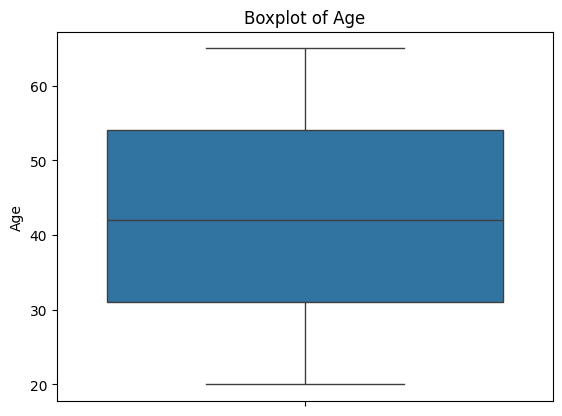

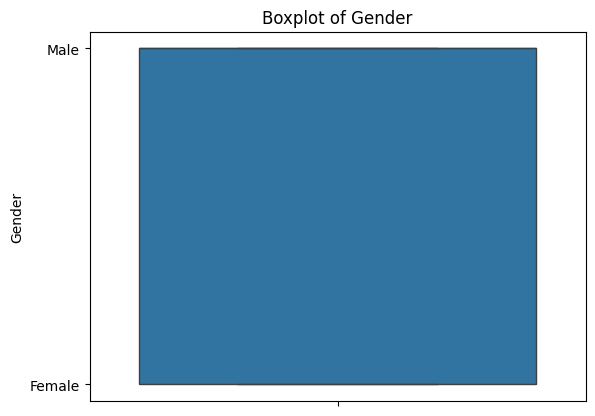

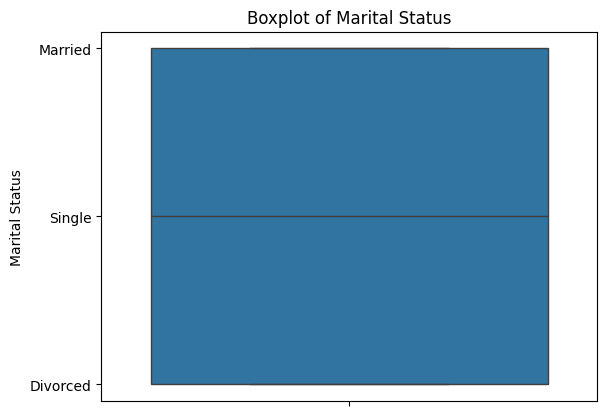

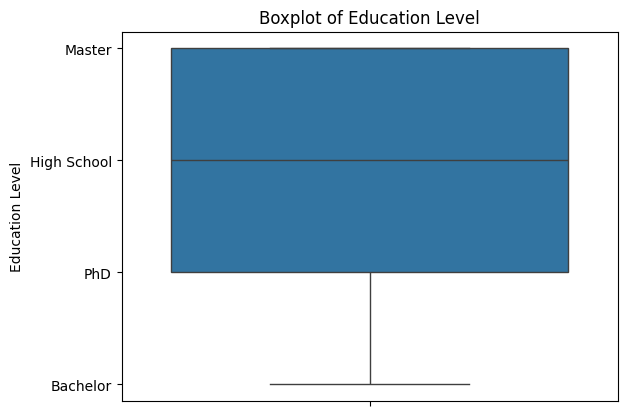

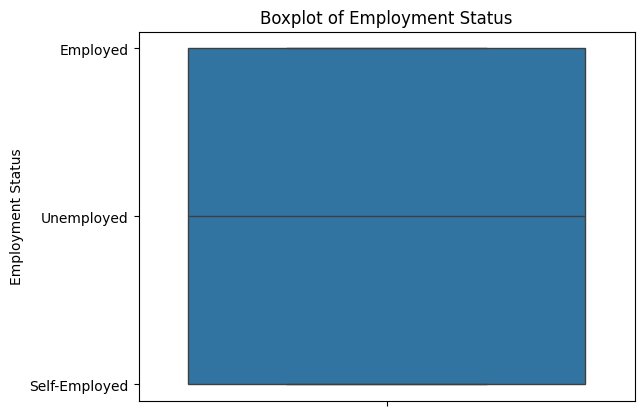

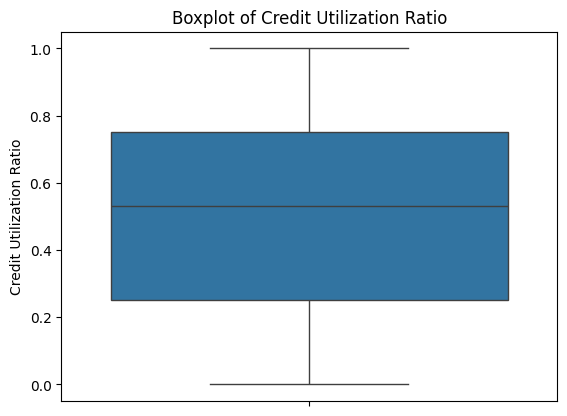

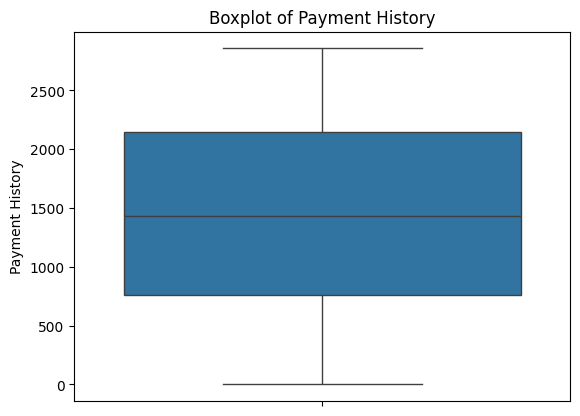

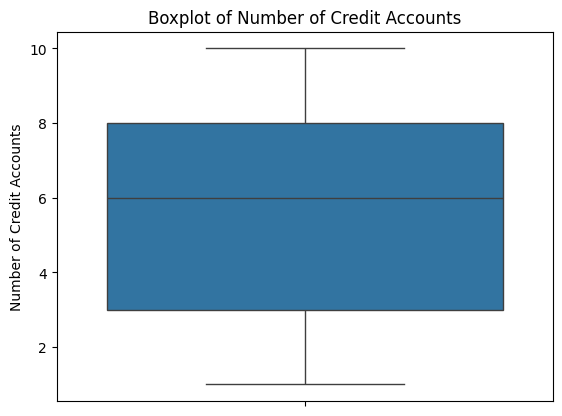

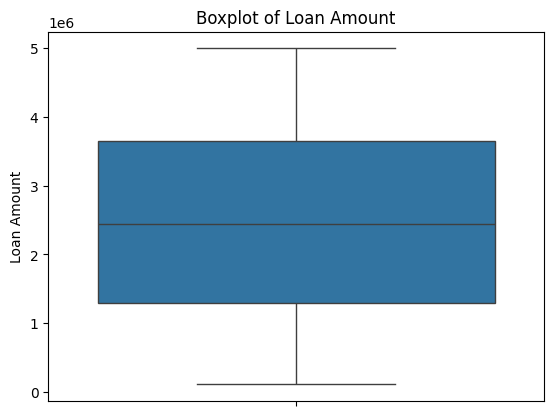

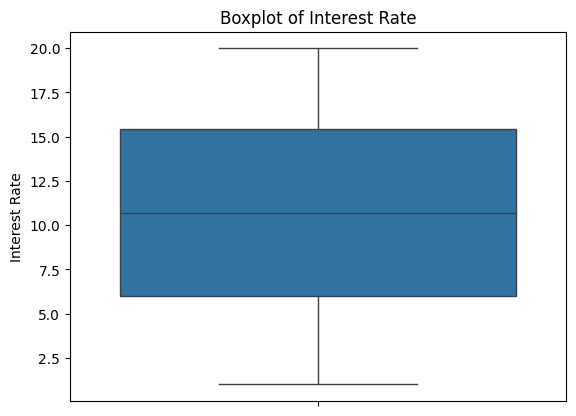

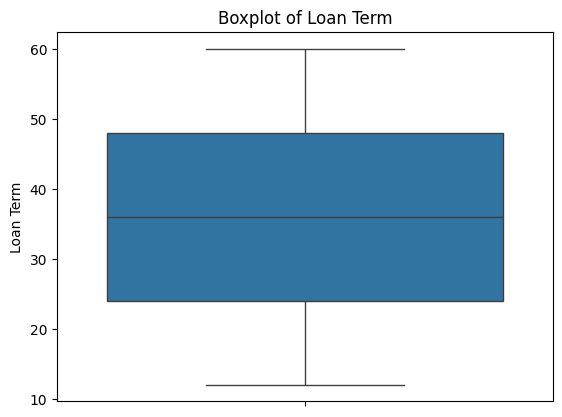

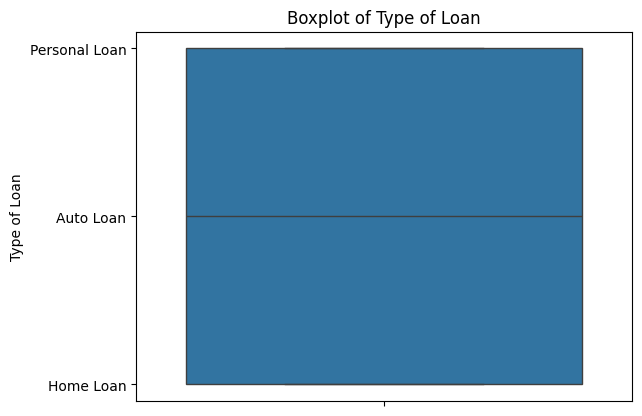

In [27]:
import  matplotlib.pyplot as  plt  
import  seaborn as  sns 
for column in df.columns:
    plt.figure()
    sns.boxplot(y=df[column])
    plt.title(f"Boxplot of {column}")
    plt.show()

In [28]:
#  no  null and  no outlier  here  

x =  df.drop(columns = ['Type of Loan'])

y =  df['Type of Loan'] 

from sklearn.model_selection import  train_test_split 
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2 ,random_state = 42,stratify=y)  

In [29]:
from  sklearn.preprocessing  import  OneHotEncoder 

from  sklearn.compose  import  ColumnTransformer
from  sklearn.pipeline  import  Pipeline  
from  sklearn.impute import  SimpleImputer  
from  sklearn.preprocessing  import StandardScaler 

from sklearn.tree import DecisionTreeClassifier  

num_cols  = x_train.select_dtypes(include = ['number']).columns.to_list()
cat_cols= x_train.select_dtypes(include = ['object','category']).columns.to_list()

In [30]:
pipeline_cat  = Pipeline(steps = [
    ('imputer',SimpleImputer(strategy = 'most_frequent')),
    ('encoder',OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore'))
])


pipeline_num  = Pipeline(steps = [
    ('imputer',SimpleImputer(strategy = 'mean')),
    ('scaler',StandardScaler())
])
 


In [31]:
preprocessor =  ColumnTransformer(transformers = [
      ('cat', pipeline_cat, cat_cols),
        ('num', pipeline_num , num_cols)
])

In [32]:
DT  =  Pipeline(steps=[
    ('preprocessor',preprocessor),   
    ('classifier',DecisionTreeClassifier(random_state=42,
    max_depth=7))
 ])

In [33]:
DT.fit(x_train,y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [34]:
y_pred = DT.predict(x_test)

In [35]:
from  sklearn.metrics  import  accuracy_score
accuracy_score(y_test,y_pred)

0.31

In [36]:
# Check training accuracy vs test accuracy
print("Train accuracy:", accuracy_score(y_train, DT.predict(x_train)))
print("Test accuracy:",  accuracy_score(y_test,  DT.predict(x_test)))

Train accuracy: 0.60375
Test accuracy: 0.31


In [70]:
import  numpy as  np 
import  pandas as  pd  
df  =  pd.read_csv('C:\\Users\\Admin\\ml  models - p\\Churn_Modelling - Churn_Modelling.csv')

In [71]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

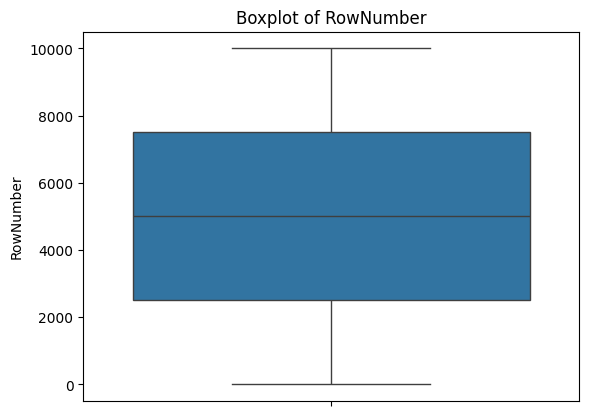

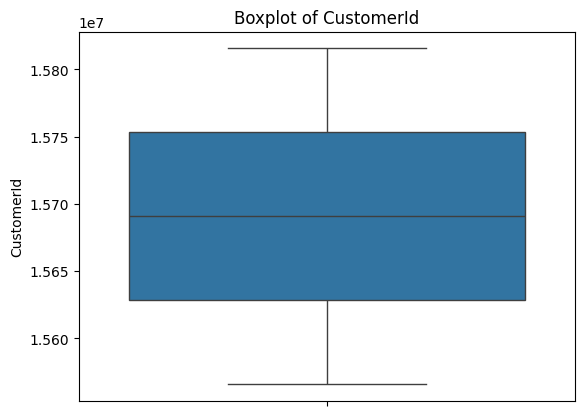

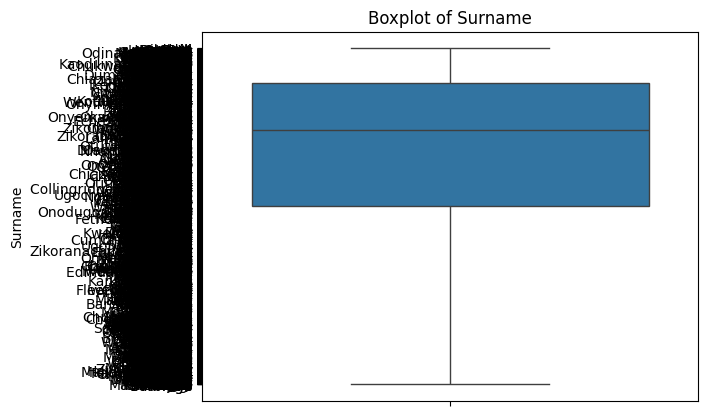

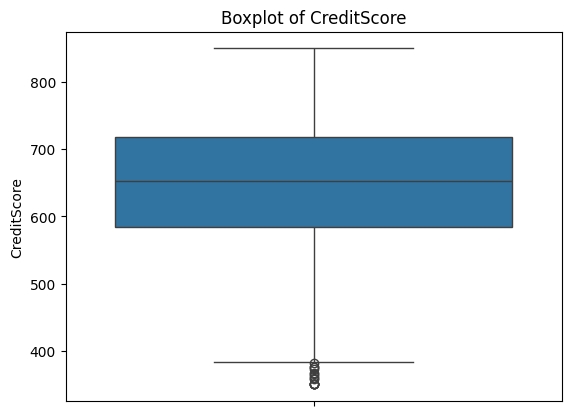

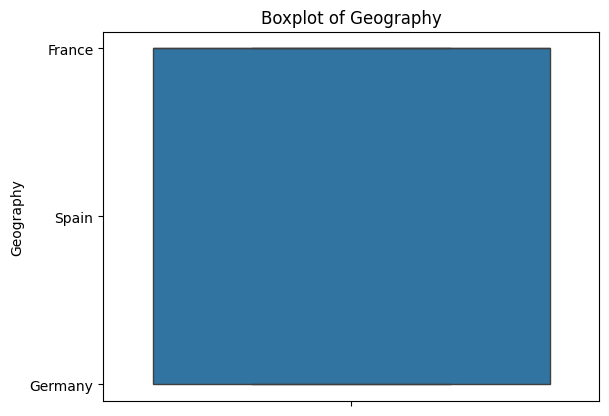

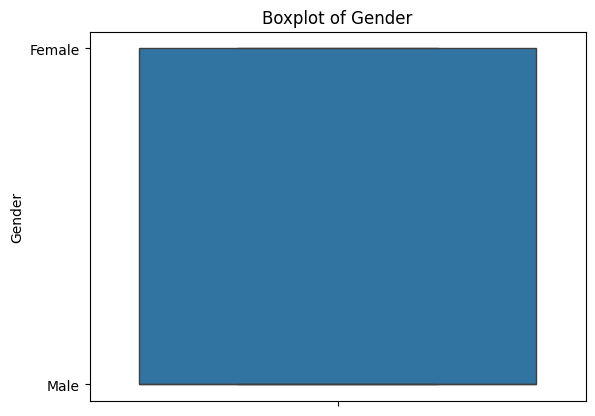

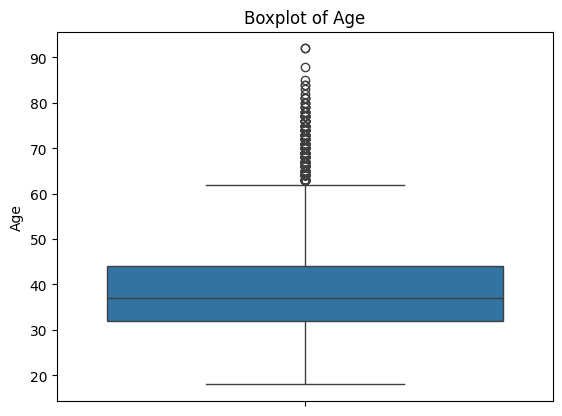

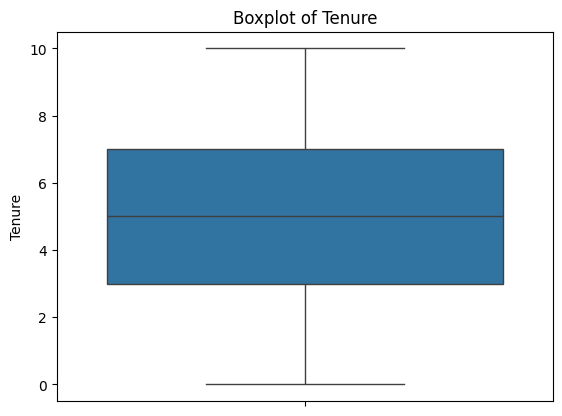

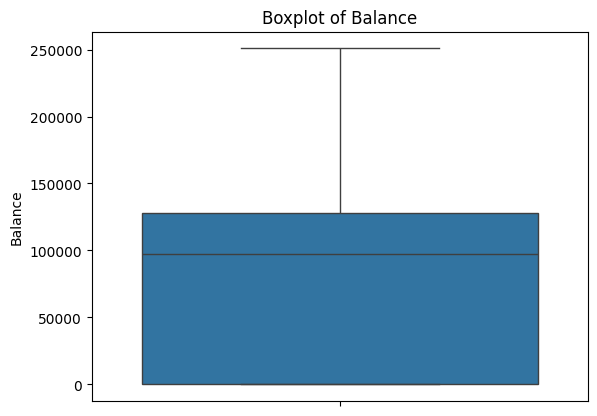

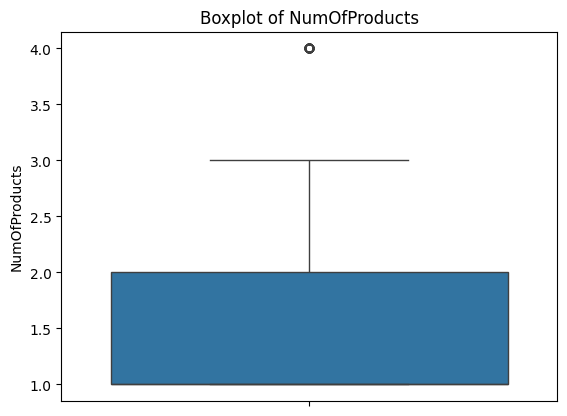

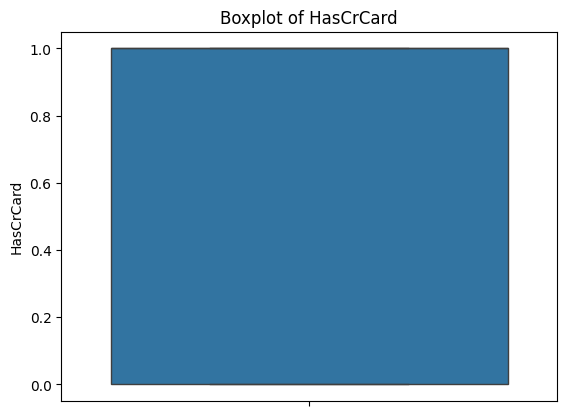

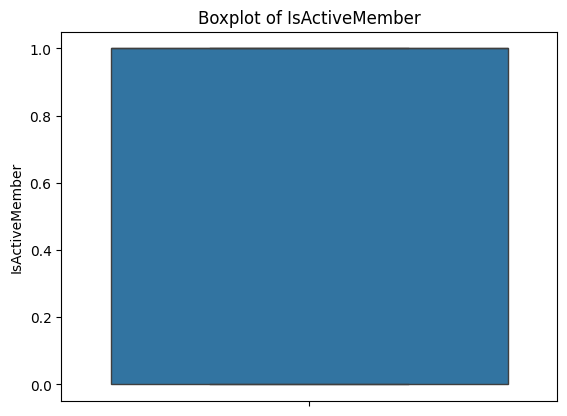

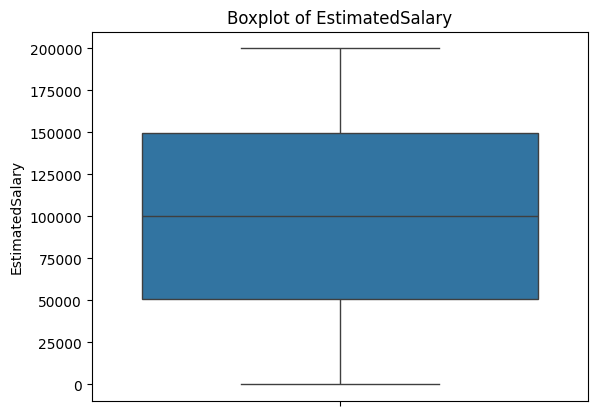

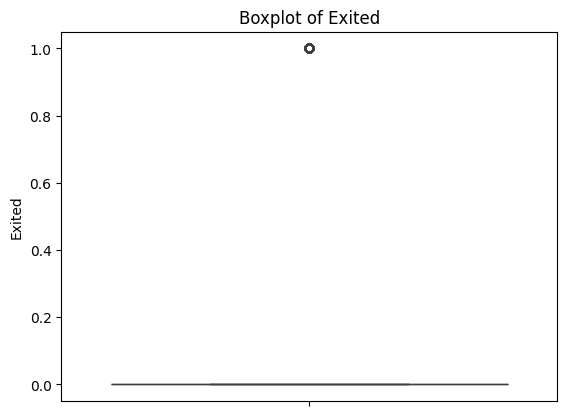

In [72]:
import  matplotlib.pyplot as  plt  
import  seaborn as  sns 
for column in df.columns:
    plt.figure()
    sns.boxplot(y=df[column])
    plt.title(f"Boxplot of {column}")
    plt.show()

In [73]:
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

In [74]:
#  no  null and  no outlier  here  

x =  df.drop(columns = ['Exited'])

y =  df['Exited'] 

from sklearn.model_selection import  train_test_split 
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2 ,random_state = 42,stratify=y)  

In [75]:
from  sklearn.preprocessing  import  OneHotEncoder 

from  sklearn.compose  import  ColumnTransformer
from  sklearn.pipeline  import  Pipeline  
from  sklearn.impute import  SimpleImputer  
from  sklearn.preprocessing  import StandardScaler 

from sklearn.tree import DecisionTreeClassifier

num_cols  = x_train.select_dtypes(include = ['number']).columns.to_list()
cat_cols= x_train.select_dtypes(include = ['object','category']).columns.to_list()

In [76]:
pipeline_cat  = Pipeline(steps = [
    ('imputer',SimpleImputer(strategy = 'most_frequent')),
    ('encoder',OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore'))
])


pipeline_num  = Pipeline(steps = [
    ('imputer',SimpleImputer(strategy = 'mean')),
    ('scaler',StandardScaler())
])
 


In [77]:
preprocessor =  ColumnTransformer(transformers = [
      ('cat', pipeline_cat, cat_cols),
        ('num', pipeline_num , num_cols)
])

In [78]:
DT  =  Pipeline(steps=[
    ('preprocessor1',preprocessor),   
    ('regression',DecisionTreeClassifier(random_state=42,
    max_depth=7))
 ])

In [79]:
DT.fit(x_train,y_train)

,steps,"[('preprocessor1', ...), ('regression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [80]:
y_pred = DT.predict(x_test) 

In [81]:
from  sklearn.metrics  import  accuracy_score  
accuracy_score(y_test,y_pred)

0.8545